In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Group 7 - Data Warehousing & OLAP with External Factors.gdoc',
 'Untitled document (1).gdoc',
 'Group 7 – Incremental Evaluation of OLAP CUBE Queries Report 1.gdoc',
 'Group 7 – Incremental Evaluation of OLAP CUBE Queries Report 2.gdoc',
 'Incremental Evaluation of OLAP Cube Queries in PostgreSQL.gdoc',
 'Incremental Evaluation of OLAP CUBE Queries Final Report.gdoc',
 'Wk 1 - Design Thinking Assignment.gdoc',
 'Wk1 - Innovation Assignment.gdoc',
 'Week2 Innovation Assignment Sai Gopal Lanka.gdoc',
 'Week 2 - Design Thinking Assignment Sai Gopal Lanka.gdoc',
 'Creative Confidence Sai Gopal Lanka.gdoc',
 'Week 3 - Innovation Assignment Sai Gopal Lanka.gdoc',
 'PROJECT 1-Sai Gopal Lanka.gdoc',
 'Week 3 - Design Thinking Assignment Sai Gopal Lanka.gdoc',
 'ASS2: Hopfield Network Group15.gdoc',
 'Week 4 - Design Thinking Sai Gopal Lanka.gdoc',
 'Week 4 - Innovation Assignment Sai Gopal Lanka.gdoc',
 'Bio + Problem Statement IDT Group6.gdoc',
 'Week 5 - Innovation Assi

In [ ]:
import pandas as pd

households = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Cloud_final_project/households.csv')
transactions = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Cloud_final_project/transactions.csv')
products = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Cloud_final_project/products.csv')

In [ ]:
print(households.shape)
print(transactions.shape)
print(products.shape)

(400, 5)
(10000, 6)
(100, 4)


In [ ]:
print(households.columns.tolist())
print(transactions.columns.tolist())
print(products.columns.tolist())

['HSHD_NUM', 'AGE', 'INCOME', 'CHILDREN', 'LOYALTY']
['HSHD_NUM', 'BASKET_NUM', 'DATE', 'PRODUCT_NUM', 'SPEND', 'UNITS']
['PRODUCT_NUM', 'DEPARTMENT', 'COMMODITY', 'BRAND']


In [ ]:
households.columns = households.columns.str.strip().str.lower()
transactions.columns = transactions.columns.str.strip().str.lower()
products.columns = products.columns.str.strip().str.lower()

print(households.columns.tolist())
print(transactions.columns.tolist())
print(products.columns.tolist())

['hshd_num', 'age', 'income', 'children', 'loyalty']
['hshd_num', 'basket_num', 'date', 'product_num', 'spend', 'units']
['product_num', 'department', 'commodity', 'brand']


In [ ]:
data = transactions.merge(households, on="hshd_num", how="left") \
                   .merge(products, on="product_num", how="left")

print(data.shape)
data.head()

(10000, 13)


,hshd_num,basket_num,date,product_num,spend,units,age,income,children,loyalty,department,commodity,brand
0,239,95677,2019-01-01 00:00:00,1071,90.91,3,44,119780,2,Yes,Snacks,Organic,National
1,377,12837,2019-01-01 01:00:00,1075,57.96,3,32,57355,3,Yes,Snacks,Organic,National
2,266,50077,2019-01-01 02:00:00,1073,7.89,3,33,92856,1,Yes,Snacks,Organic,Private
3,359,89915,2019-01-01 03:00:00,1013,58.39,1,41,108859,1,No,Dairy,Regular,National
4,340,14239,2019-01-01 04:00:00,1072,15.36,3,56,121362,1,Yes,Grocery,Organic,Private


In [ ]:
sample_hh10 = data[data["hshd_num"] == 10].copy()

sample_hh10 = sample_hh10.sort_values(
    by=["hshd_num", "basket_num", "date", "product_num", "department", "commodity"]
)

sample_hh10.head(20)

,hshd_num,basket_num,date,product_num,spend,units,age,income,children,loyalty,department,commodity,brand
1111,10,12693,2019-02-16 07:00:00,1021,44.79,1,35,110738,3,Yes,Snacks,Regular,Private
9264,10,15432,2020-01-22 00:00:00,1065,15.09,2,35,110738,3,Yes,Beverages,Regular,Private
8960,10,15900,2020-01-09 08:00:00,1071,76.02,1,35,110738,3,Yes,Snacks,Organic,National
5818,10,16563,2019-08-31 10:00:00,1017,55.87,2,35,110738,3,Yes,Grocery,Organic,Private
9445,10,25409,2020-01-29 13:00:00,1059,48.49,3,35,110738,3,Yes,Dairy,Regular,National
4139,10,25945,2019-06-22 11:00:00,1058,19.67,2,35,110738,3,Yes,Dairy,Organic,Private
1199,10,33086,2019-02-19 23:00:00,1005,49.29,1,35,110738,3,Yes,Beverages,Organic,National
6435,10,33118,2019-09-26 03:00:00,1090,59.64,2,35,110738,3,Yes,Dairy,Regular,National
513,10,38460,2019-01-22 09:00:00,1081,70.63,2,35,110738,3,Yes,Grocery,Regular,National
6707,10,42959,2019-10-07 11:00:00,1014,61.72,3,35,110738,3,Yes,Dairy,Organic,National


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# make sure date is proper datetime
data["date"] = pd.to_datetime(data["date"])

# basic KPIs
total_sales = data["spend"].sum()
total_units = data["units"].sum()
total_households = data["hshd_num"].nunique()
total_products = data["product_num"].nunique()

print("Total Sales:", total_sales)
print("Total Units:", total_units)
print("Total Households:", total_households)
print("Total Products:", total_products)

Total Sales: 509377.12999999995
Total Units: 25065
Total Households: 400
Total Products: 100


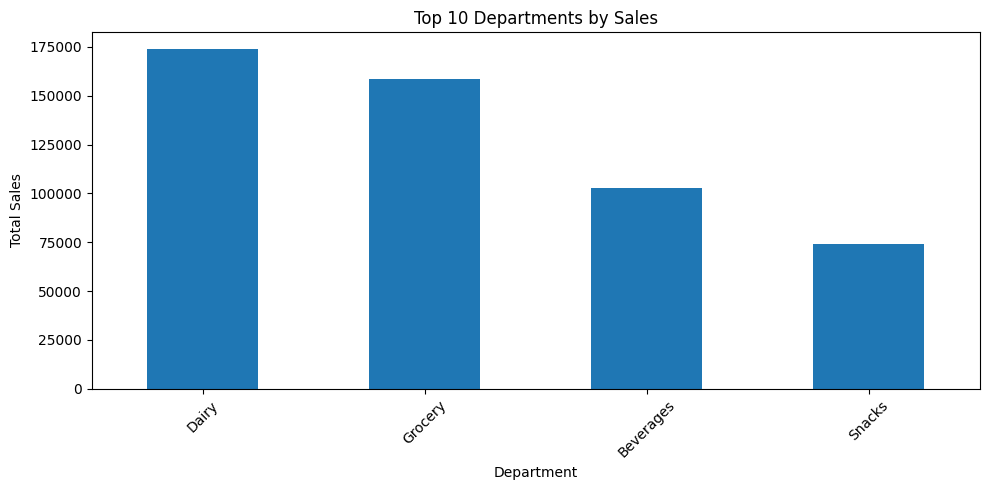

In [ ]:
# 1. Sales by department
sales_by_department = data.groupby("department")["spend"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sales_by_department.plot(kind="bar")
plt.title("Top 10 Departments by Sales")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

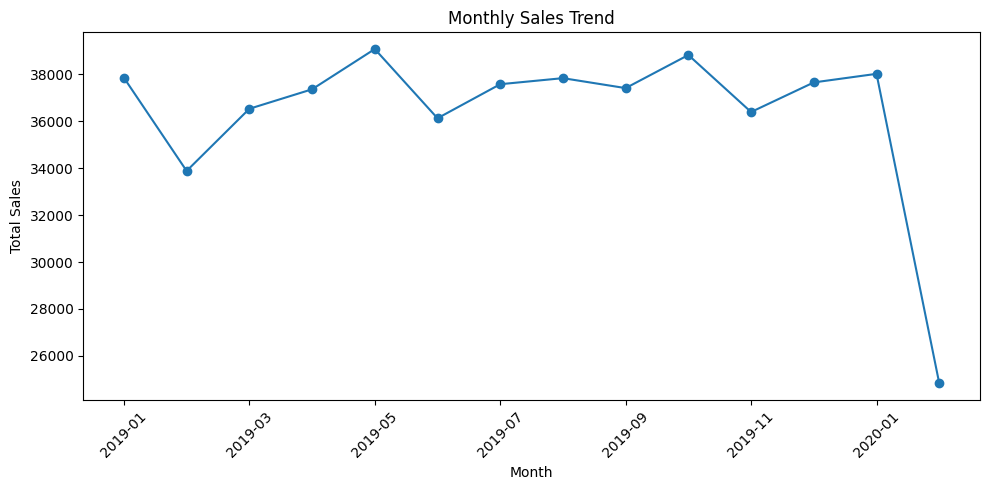

In [ ]:
# 2. Monthly sales trend
monthly_sales = data.groupby(data["date"].dt.to_period("M"))["spend"].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10,5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

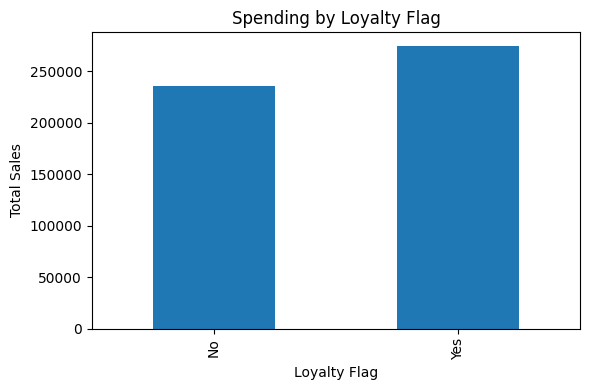

In [ ]:
# 3. Loyalty vs non-loyalty spending
loyalty_sales = data.groupby("loyalty")["spend"].sum()

plt.figure(figsize=(6,4))
loyalty_sales.plot(kind="bar")
plt.title("Spending by Loyalty Flag")
plt.xlabel("Loyalty Flag")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

In [ ]:
data.head()

,hshd_num,basket_num,date,product_num,spend,units,age,income,children,loyalty,department,commodity,brand
0,239,95677,2019-01-01 00:00:00,1071,90.91,3,44,119780,2,Yes,Snacks,Organic,National
1,377,12837,2019-01-01 01:00:00,1075,57.96,3,32,57355,3,Yes,Snacks,Organic,National
2,266,50077,2019-01-01 02:00:00,1073,7.89,3,33,92856,1,Yes,Snacks,Organic,Private
3,359,89915,2019-01-01 03:00:00,1013,58.39,1,41,108859,1,No,Dairy,Regular,National
4,340,14239,2019-01-01 04:00:00,1072,15.36,3,56,121362,1,Yes,Grocery,Organic,Private


Household search logic

In [ ]:
def get_household_data(hshd_id):
    result = data[data["hshd_num"] == hshd_id].copy()
    result = result.sort_values(
        by=["hshd_num", "basket_num", "date", "product_num", "department", "commodity"]
    )
    return result

hh10 = get_household_data(10)
print(hh10.shape)
hh10.head(20)

(28, 13)


,hshd_num,basket_num,date,product_num,spend,units,age,income,children,loyalty,department,commodity,brand
1111,10,12693,2019-02-16 07:00:00,1021,44.79,1,35,110738,3,Yes,Snacks,Regular,Private
9264,10,15432,2020-01-22 00:00:00,1065,15.09,2,35,110738,3,Yes,Beverages,Regular,Private
8960,10,15900,2020-01-09 08:00:00,1071,76.02,1,35,110738,3,Yes,Snacks,Organic,National
5818,10,16563,2019-08-31 10:00:00,1017,55.87,2,35,110738,3,Yes,Grocery,Organic,Private
9445,10,25409,2020-01-29 13:00:00,1059,48.49,3,35,110738,3,Yes,Dairy,Regular,National
4139,10,25945,2019-06-22 11:00:00,1058,19.67,2,35,110738,3,Yes,Dairy,Organic,Private
1199,10,33086,2019-02-19 23:00:00,1005,49.29,1,35,110738,3,Yes,Beverages,Organic,National
6435,10,33118,2019-09-26 03:00:00,1090,59.64,2,35,110738,3,Yes,Dairy,Regular,National
513,10,38460,2019-01-22 09:00:00,1081,70.63,2,35,110738,3,Yes,Grocery,Regular,National
6707,10,42959,2019-10-07 11:00:00,1014,61.72,3,35,110738,3,Yes,Dairy,Organic,National


In [ ]:
hh25 = get_household_data(25)
print(hh25.shape)
hh25.head(10)

(33, 13)


,hshd_num,basket_num,date,product_num,spend,units,age,income,children,loyalty,department,commodity,brand
7847,25,13143,2019-11-23 23:00:00,1098,51.14,4,57,58251,2,No,Snacks,Organic,National
2270,25,13691,2019-04-05 14:00:00,1053,21.19,1,57,58251,2,No,Beverages,Organic,Private
3411,25,17897,2019-05-23 03:00:00,1013,8.05,3,57,58251,2,No,Dairy,Regular,National
5341,25,18250,2019-08-11 13:00:00,1058,45.38,2,57,58251,2,No,Dairy,Organic,Private
405,25,18625,2019-01-17 21:00:00,1094,32.93,3,57,58251,2,No,Beverages,Organic,Private
6022,25,22279,2019-09-08 22:00:00,1027,65.81,2,57,58251,2,No,Dairy,Organic,Private
3421,25,24263,2019-05-23 13:00:00,1033,81.51,3,57,58251,2,No,Dairy,Organic,Private
9330,25,24693,2020-01-24 18:00:00,1072,95.28,3,57,58251,2,No,Grocery,Organic,Private
8462,25,29195,2019-12-19 14:00:00,1089,78.54,1,57,58251,2,No,Dairy,Organic,Private
9733,25,35280,2020-02-10 13:00:00,1076,18.82,3,57,58251,2,No,Beverages,Organic,National


Dashboard Metrics Table

In [ ]:
kpi_table = pd.DataFrame({
    "Metric": [
        "Total Sales",
        "Total Units",
        "Total Households",
        "Total Products",
        "Average Spend per Transaction"
    ],
    "Value": [
        data["spend"].sum(),
        data["units"].sum(),
        data["hshd_num"].nunique(),
        data["product_num"].nunique(),
        data.groupby("basket_num")["spend"].sum().mean()
    ]
})

kpi_table

,Metric,Value
0,Total Sales,509377.130000
1,Total Units,25065.000000
2,Total Households,400.000000
3,Total Products,100.000000
4,Average Spend per Transaction,53.942299


In [ ]:
kpi_table.to_csv("kpi_table.csv", index=False)
print("KPI table saved")

KPI table saved


ML Part 1 - CLV

In [ ]:
household_clv = data.groupby("hshd_num").agg({
    "spend": "sum",
    "units": "sum",
    "basket_num": "nunique"
}).reset_index()

household_clv.columns = ["hshd_num", "total_spend", "total_units", "total_baskets"]
household_clv.head()

,hshd_num,total_spend,total_units,total_baskets
0,1,1164.08,56,23
1,2,1655.56,58,25
2,3,1119.72,58,24
3,4,1172.20,46,20
4,5,1090.29,43,19


In [ ]:
demo_cols = [col for col in households.columns if col != "hshd_num"]
household_clv = household_clv.merge(households, on="hshd_num", how="left")
household_clv.head()

,hshd_num,total_spend,total_units,total_baskets,age,income,children,loyalty
0,1,1164.08,56,23,63,144692,1,Yes
1,2,1655.56,58,25,53,117142,1,Yes
2,3,1119.72,58,24,39,117235,3,No
3,4,1172.20,46,20,67,84021,1,No
4,5,1090.29,43,19,32,96412,1,Yes


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

clv_df = household_clv.copy()

for col in clv_df.columns:
    if clv_df[col].dtype == "object":
        clv_df[col] = clv_df[col].astype(str)
        le = LabelEncoder()
        clv_df[col] = le.fit_transform(clv_df[col])

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = clv_df.drop(columns=["hshd_num", "total_spend"])
y = clv_df["total_spend"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 115.37195124999991
R2 Score: 0.7120521801397881


ML Part 2 - Churn

In [ ]:
churn_df = data.groupby("hshd_num").agg({
    "basket_num": "nunique",
    "spend": "sum",
    "units": "sum"
}).reset_index()

churn_df.columns = ["hshd_num", "total_baskets", "total_spend", "total_units"]

threshold = churn_df["total_baskets"].median()
churn_df["churn_risk"] = (churn_df["total_baskets"] < threshold).astype(int)

churn_df = churn_df.merge(households, on="hshd_num", how="left")
churn_df.head()

,hshd_num,total_baskets,total_spend,total_units,churn_risk,age,income,children,loyalty
0,1,23,1164.08,56,1,63,144692,1,Yes
1,2,25,1655.56,58,0,53,117142,1,Yes
2,3,24,1119.72,58,1,39,117235,3,No
3,4,20,1172.20,46,1,67,84021,1,No
4,5,19,1090.29,43,1,32,96412,1,Yes


In [ ]:
churn_model_df = churn_df.copy()

for col in churn_model_df.columns:
    if churn_model_df[col].dtype == "object":
        churn_model_df[col] = churn_model_df[col].astype(str)
        le = LabelEncoder()
        churn_model_df[col] = le.fit_transform(churn_model_df[col])

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = churn_model_df.drop(columns=["hshd_num", "churn_risk"])
y = churn_model_df["churn_risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       1.00      1.00      1.00        40

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [ ]:
data.to_csv("merged_retail_data.csv", index=False)
household_clv.to_csv("household_clv.csv", index=False)
churn_df.to_csv("churn_data.csv", index=False)

print("Files saved")

Files saved


In [ ]:
from google.colab import files

files.download("merged_retail_data.csv")
files.download("household_clv.csv")
files.download("churn_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>